In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from typing import Dict, List
import torch.nn as nn
import torch.optim as optim

# Libs

## data_loading

In [2]:
def _extract_U_and_nu_from_npz(filepath):
    """
    Extract U (trajectory) and nu (viscosity) from a .npz file.
    
    Args:
        filepath: Path to the .npz file
        
    Returns:
        U: numpy array of shape (T, N) containing the trajectory
        nu: float value of the viscosity parameter
    """
    data = np.load(str(filepath), allow_pickle=True)
    
    # Extract the trajectory (usually stored as 'U' or 'u')
    if 'U' in data.files:
        U = data['U']
    elif 'u' in data.files:
        U = data['u']
    else:
        # Try to find the main data array (usually the largest one)
        arrays = {k: data[k] for k in data.files if isinstance(data[k], np.ndarray) and data[k].ndim >= 2}
        if not arrays:
            raise ValueError(f"No suitable trajectory array found in {filepath}")
        # Take the array with the most elements
        U = max(arrays.values(), key=lambda x: x.size)
    
    # Extract viscosity parameter
    if 'nu' in data.files:
        nu = float(data['nu'])
    elif 'viscosity' in data.files:
        nu = float(data['viscosity'])
    else:
        raise ValueError(f"No viscosity parameter ('nu' or 'viscosity') found in {filepath}")
    
    return U, nu

def _align_array_to_shape(arr, target_T, target_N):
    """
    Align array to target shape by truncating time and padding/cropping space.
    
    Args:
        arr: numpy array of shape (T, N)
        target_T: target time steps
        target_N: target spatial points
        
    Returns:
        aligned array of shape (target_T, target_N)
    """
    T, N = arr.shape
    
    # Truncate time dimension
    arr = arr[:target_T, :]
    
    # Handle spatial dimension
    if N == target_N:
        return arr
    elif N < target_N:
        # Pad with zeros
        pad_width = ((0, 0), (0, target_N - N))
        return np.pad(arr, pad_width, mode='constant', constant_values=0)
    else:
        # Crop from center
        start_idx = (N - target_N) // 2
        return arr[:, start_idx:start_idx + target_N]

class BurgersViscosityDataset():
    """
    Groups many trajectories by viscosity, like in sam_cnn.py.
    Returns (initial_field, full_trajectory, nu).
    """
    def __init__(self, datasets: list[torch.Tensor], viscosities: list[float]):
        # datasets: list de tensors (num_samples, T, N)
        self.data = []
        self.nu = []
        for data, nu in zip(datasets, viscosities):
            num_samples = data.shape[0]
            self.data.append(data)
            self.nu.append(torch.full((num_samples, 1), nu, dtype=torch.float32))

        self.data = torch.cat(self.data, dim=0)  # (total_samples, T, N)
        self.nu = torch.cat(self.nu, dim=0)      # (total_samples, 1)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        full_trajectory = self.data[idx]        # (T, N)
        initial_field = full_trajectory[0, :]   # (N,)
        nu = self.nu[idx]                       # (1,)
        return initial_field, full_trajectory, nu

def collect_generated_burgers(root_dir: str, history_len: int):
    """
    Simplified version of collect_generated_burgers() from sam_cnn.py.
    - Filters files that are too short (T < history_len+1)
    - Groups by viscosity
    - Aligns time by truncation and space by padding/crop.
    """
    root = Path(root_dir)
    files = sorted(root.glob("**/*.npz"))
    if not files:
        raise FileNotFoundError(f"No .npz files found in {root}")
    MIN_T = history_len + 1

    groups = {}
    shapes = {}
    for p in files:
        try:
            U, nu = _extract_U_and_nu_from_npz(p)
        except Exception as e:
            print(f"❌ Skipping file (invalid or corrupted .npz): {p} | error: {e}")
            continue
        T, N = U.shape
        if T < MIN_T:
            continue
        groups.setdefault(nu, []).append(U)
        shapes.setdefault(nu, []).append((T, N))

    datasets = []
    viscosities = []
    for nu, arrs in groups.items():
        Ts = [a.shape[0] for a in arrs]
        Ns = [a.shape[1] for a in arrs]
        target_T = min(Ts)
        target_N = max(Ns)
        aligned = []
        for a in arrs:
            a2 = _align_array_to_shape(a, target_T, target_N)
            aligned.append(a2)
        arr_tensor = torch.tensor(np.stack(aligned, axis=0), dtype=torch.float32)
        datasets.append(arr_tensor)
        viscosities.append(float(nu))
    return datasets, viscosities

def create_generated_dataloaders_from_folders(
    train_dir: str,
    test_dir: str,
    history_len: int,
    batch_size: int,
):
    """
    Creates train/test loaders from separate train and test directories.
    
    Args:
        train_dir: Path to the training data folder
        test_dir: Path to the test data folder
        history_len: Minimum history length required
        batch_size: Batch size for DataLoaders
        
    Returns:
        train_loader, test_loader
    """
    # Load training data
    train_datasets, train_viscosities = collect_generated_burgers(train_dir, history_len)
    train_dataset = BurgersViscosityDataset(train_datasets, train_viscosities)
    
    # Load test data
    test_datasets, test_viscosities = collect_generated_burgers(test_dir, history_len)
    test_dataset = BurgersViscosityDataset(test_datasets, test_viscosities)
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader


# --------- Function to quickly look at the dataset ---------

def show_random_sample(dataset, idx: int):
    """
    Displays the shape of an example + a small heatmap of the trajectory.
    """
    # if idx is None:
    #     idx = random.randint(0, len(dataset) - 1)
    initial_field, traj, nu = dataset[idx]
    print(f"Sample {idx} | nu={float(nu):.4f}")
    print(" initial_field:", initial_field.shape)
    print(" trajectory   :", traj.shape)

    traj_np = traj.numpy().T  # (space, time)
    plt.figure(figsize=(6, 3))
    plt.imshow(traj_np, aspect="auto", cmap="viridis")
    plt.colorbar(label="u(x,t)")
    plt.xlabel("time")
    plt.ylabel("space")
    plt.title(f"Trajectory (nu={float(nu):.4f})")
    plt.tight_layout()
    plt.show()

def validate_npz_files(root_dir: str, max_examples: int | None = 20):
    """
    Scans .npz files under root_dir and returns two lists: good_files and bad_files.
    Each item in good_files contains path, size (bytes), keys, and nu (if present).
    Each item in bad_files contains path and error string.

    This is useful to quickly locate corrupted or incompatible npz files.
    """
    from pathlib import Path
    root = Path(root_dir)
    files = sorted(root.glob("**/*.npz"))
    good = []
    bad = []
    for i, p in enumerate(files):
        try:
            size = p.stat().st_size
            data = np.load(str(p), allow_pickle=True)
            keys = list(data.files)
            nu = float(data["nu"]) if "nu" in data.files else None
            good.append({"path": str(p), "size": size, "keys": keys, "nu": nu})
        except Exception as e:
            bad.append({"path": str(p), "error": str(e)})
        if max_examples is not None and i >= max_examples:
            break
    return good, bad


## models

In [3]:
class TransformerController(nn.Module):
    """
    Input: temporal patch sequence + viscosity
    patch_seq: (B, seq_len, patch_size)
    nu       : (B, 1)
    -> scalar prediction with learned temporal weights (attention).
    """
    def __init__(self, patch_size: int, hidden_size: int = 64):
        super().__init__()
        self.patch_size = patch_size
        self.hidden_size = hidden_size

        # On encode chaque (patch + nu) en un embedding
        self.embed = nn.Sequential(
            nn.Linear(patch_size + 1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )

        # Score d'attention pour chaque time step
        self.attn = nn.Linear(hidden_size, 1)

        # Tête finale pour prédire le scalaire à partir du contexte agrégé
        self.fc_out = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, patch_seq, nu):
        # patch_seq: (B, seq_len, patch_size)
        # nu      : (B, 1)
        B, L, P = patch_seq.shape
        assert P == self.patch_size

        # On répète nu sur la dimension temporelle
        nu_expanded = nu.unsqueeze(1).expand(-1, L, 1)      # (B, L, 1)
        x = torch.cat([patch_seq, nu_expanded], dim=-1)     # (B, L, P+1)

        # Encodage pas de temps par pas de temps
        h = self.embed(x)                                   # (B, L, hidden)

        # Scores d'attention pour chaque time step
        scores = self.attn(h).squeeze(-1)                   # (B, L)
        weights = torch.softmax(scores, dim=-1)             # (B, L)

        # Combinaison pondérée des embeddings temporels
        context = (h * weights.unsqueeze(-1)).sum(dim=1)    # (B, hidden)

        # Prédiction finale
        y = self.fc_out(context)                            # (B, 1)
        return y.squeeze(1)                                 # (B,)

## training

In [4]:
def build_patches_from_sequence(fields_seq, r: int, patch_size: int):
    """
    sam_cnn version:
    fields_seq: (B, L, N) -> (B*N, L, patch_size)
    """
    B, L, N = fields_seq.shape
    patches_list = []
    for l in range(L):
        field_l = fields_seq[:, l, :]                       # (B, N)
        padded_l = F.pad(field_l, (r, r), mode='replicate') # (B, N+2r)
        patches_l = padded_l.unfold(1, patch_size, 1)       # (B, N, P)
        patches_list.append(patches_l)
    patches_seq = torch.stack(patches_list, dim=2)          # (B, N, L, P)
    return patches_seq.reshape(B * N, L, patch_size)


def train_rnn_patch(
    model,
    dataloader,
    device: torch.device,
    chunk_size: int = 3,
    num_epochs: int = 30,
    patch_radius: int = 1,
):
    """
    Loop inspired by rnn.py:
    - we take temporal chunks (chunk_size) as input
    - target: field at time t+chunk_size
    """
    model.to(device)
    model.train()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    patch_size = 2 * patch_radius + 1

    epoch_losses: List[float] = []

    for epoch in range(num_epochs):
        total_loss = 0.0
        for init_field, true_traj, nu in dataloader:
            true_traj = true_traj.to(device)  # (B, T, N)
            nu = nu.to(device)                # (B, 1)
            B, T, N = true_traj.shape

            all_preds = []
            all_targets = []
            for t in range(T - chunk_size):
                current_chunk = true_traj[:, t : t + chunk_size, :]    # (B, chunk_size, N)
                next_true = true_traj[:, t + chunk_size, :]            # (B, N)

                # patches: (B, chunk_size, N, P) -> (B*N, chunk_size, P)
                patches = build_patches_from_sequence(current_chunk, patch_radius, patch_size)
                # patches: (B*N, chunk_size, P)
                nu_expanded = nu.unsqueeze(1).expand(-1, N, -1).reshape(B * N, 1)  # (B*N,1)
                pred_next = model(patches, nu_expanded).reshape(B, N)              # (B,N)

                all_preds.append(pred_next)
                all_targets.append(next_true)

            if not all_preds:
                continue
            pred_traj = torch.stack(all_preds, dim=1)      # (B, T', N)
            target_traj = torch.stack(all_targets, dim=1)  # (B, T', N)

            loss = criterion(pred_traj, target_traj)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        epoch_losses.append(avg_loss)
        print(f"[RNN] Epoch {epoch+1}/{num_epochs} - MSE: {avg_loss:.6e}")

    return epoch_losses

## visualization

In [5]:
def plot_trajectories(true_traj: torch.Tensor, pred_traj: torch.Tensor, title_suffix: str = ""):
    """
    true_traj, pred_traj : (T, N) (single trajectory)
    """
    true_np = true_traj.cpu().numpy().T   # (N, T)
    pred_np = pred_traj.cpu().numpy().T
    err_np  = (true_np - pred_np) ** 2

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(true_np, aspect="auto", cmap="viridis")
    plt.colorbar(label="u(x,t)")
    plt.xlabel("time")
    plt.ylabel("space")
    plt.title("True" + title_suffix)

    plt.subplot(1, 3, 2)
    plt.imshow(pred_np, aspect="auto", cmap="viridis")
    plt.colorbar(label="u(x,t)")
    plt.xlabel("time")
    plt.ylabel("space")
    plt.title("Predicted" + title_suffix)

    plt.subplot(1, 3, 3)
    plt.imshow(err_np, aspect="auto", cmap="inferno")
    plt.colorbar(label="squared error")
    plt.xlabel("time")
    plt.ylabel("space")
    plt.title("Error")

    plt.tight_layout()
    plt.show()


def plot_losses(train_losses, test_losses=None, title: str = "Loss per epoch"):
    plt.figure(figsize=(6, 4))
    plt.plot(train_losses, marker="o", label="train")
    if test_losses is not None:
        plt.plot(test_losses, marker="s", label="test")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

## evaluation

In [6]:
def resolve_nu_target(
    loader,
    plot_nu=None,
    selected_nu=None,
    list_nus: bool = False,
    verbose: bool = True,
):
    """Utility to resolve a nu target from loader and a plot specifier.

    Arguments:
      loader: data loader or iterable used to enumerate available nu values
      plot_nu: one of None | float | 'min'|'max'|'idx:N'|'random'|'list'|str->float
      selected_nu: if provided, priority target (returned directly)
      list_nus: if True -> print the list of nus and return None
      verbose: prints helpful messages

    Returns:
      float | None
    """
    nus = []
    try:
        nus = get_loader_nu_values(loader)
    except Exception:
        if verbose:
            print("resolve_nu_target: unable to enumerate nus from loader")

    if list_nus and verbose:
        print(f"Loader contains {len(nus)} unique nu values: {nus}")

    if selected_nu is not None:
        if verbose:
            print(f"Using provided selected_nu: {selected_nu}")
        return float(selected_nu)

    if plot_nu is None:
        return None

    # numeric types: choose closest if available
    if isinstance(plot_nu, (int, float)):
        if nus:
            val = float(plot_nu)
            closest = min(nus, key=lambda x: abs(x - val))
            if abs(closest - val) > 1e-8 and verbose:
                print(f"Requested nu {val} not in loader; using nearest available {closest}.")
            return float(closest)
        else:
            return float(plot_nu)

    if isinstance(plot_nu, str):
        s = plot_nu.strip().lower()
        if s == 'list':
            # already printed nus above
            return None
        if s == 'min' and nus:
            return float(min(nus))
        if s == 'max' and nus:
            return float(max(nus))
        if s.startswith('idx:') and nus:
            try:
                idx = int(s.split(':', 1)[1])
                if 0 <= idx < len(nus):
                    return float(nus[idx])
                else:
                    if verbose:
                        print(f"resolve_nu_target: index {idx} out of range (0..{len(nus)-1})")
                    return None
            except Exception:
                if verbose:
                    print("resolve_nu_target: invalid idx format; use 'idx:N'")
                return None
        if s == 'random' and nus:
            import random
            return float(random.choice(nus))
        # fallback: try parse numeric string
        try:
            val = float(s)
            if nus:
                closest = min(nus, key=lambda x: abs(x - val))
                if abs(closest - val) > 1e-8 and verbose:
                    print(f"Requested nu {val} not in loader; using nearest available {closest}.")
                return float(closest)
            else:
                return float(val)
        except Exception:
            if verbose:
                print(f"resolve_nu_target: could not parse PLOT_NU string '{plot_nu}'")
            return None


def get_loader_nu_values(loader):
    """Return a sorted list of unique nu values found in a DataLoader or dataset.

    The loader can be a DataLoader or any iterable returning (init, traj, nu).
    """
    nus = set()
    for batch in loader:
        try:
            nu = batch[2]
        except Exception:
            _, _, nu = batch

        if isinstance(nu, torch.Tensor):
            for v in nu.reshape(-1).cpu().numpy():
                try:
                    nus.add(float(v))
                except Exception:
                    continue
        else:
            try:
                nus.add(float(nu))
            except Exception:
                continue
    return sorted(nus)


def evaluate_model_on_sample(model, train_loader, device, patch_radius, max_val=1.0, val_range=1.0, chunk_size=3, nu_target=None):
    """
    Evaluates a model on a sample and returns performance metrics.
    Compatible with CNN and RNN.
    
    Args:
        model: The trained CNN or RNN model
        train_loader: DataLoader containing the data
        device: PyTorch device (cuda or cpu) 
        patch_radius: Radius of spatial patches
        max_val: Maximum value for PSNR calculation
        val_range: Value range for SSIM calculation
            chunk_size: Size of temporal chunks for RNN (ignored for CNN)
            nu_target: If provided, tries to pick a sample with this viscosity value from the loader.
    
    Returns:
        dict: Dictionary containing metrics and trajectories
            - 'true_traj': Real trajectory
            - 'pred_traj': Predicted trajectory
            - 'nu_value': Viscosity value
            - 'psnr': PSNR score
            - 'ssim': SSIM score
            - 'mse': Mean squared error
            - 'r2': R² score
    """
    true_traj, pred_traj, nu_value = generate_model_predictions(
        model,
        train_loader,
        device,
        patch_radius,
        verbose=False,
        chunk_size=chunk_size,
        nu_target=nu_target,
    )
    
    # Calculate metrics
    psnr_score = psnr(true_traj, pred_traj, max_val=max_val)
    ssim_score = ssim(true_traj, pred_traj, val_range=val_range)
    mse_score = torch.mean((true_traj - pred_traj)**2).item()
    r2_score_val = r2_score(pred_traj, true_traj)
    
    return {
        'true_traj': true_traj,
        'pred_traj': pred_traj,
        'nu_value': nu_value,
        'psnr': psnr_score,
        'ssim': ssim_score,
        'mse': mse_score,
        'r2': r2_score_val
    }


def display_evaluation_results(evaluation_results, show_plots=True):
    """
    Displays evaluation metrics and error visualizations.
    
    Args:
        evaluation_results: Dictionary returned by evaluate_model_on_sample()
        show_plots: If True, displays error plots
        
    Returns:
        tuple: (true_traj, pred_traj) for later use if needed
    """
    true_traj = evaluation_results['true_traj']
    pred_traj = evaluation_results['pred_traj']
    
    print(f"Evaluation metrics:")
    print(f"  - PSNR: {evaluation_results['psnr']:.3f} dB")
    print(f"  - SSIM: {evaluation_results['ssim']:.3f}")
    print(f"  - MSE: {evaluation_results['mse']:.6f}")
    print(f"  - R²: {evaluation_results['r2']:.4f}")
    
    if show_plots:
        # Error visualization
        error = torch.abs(true_traj - pred_traj)
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.imshow(error.cpu().numpy(), aspect='auto', cmap='hot')
        plt.colorbar(label='Absolute error')
        plt.xlabel('Spatial position')
        plt.ylabel('Time')
        plt.title('Absolute error map')
        
        plt.subplot(1, 2, 2)
        mean_error_per_time = torch.mean(error, dim=1).cpu().numpy()
        plt.plot(mean_error_per_time, 'r-', linewidth=2)
        plt.xlabel('Time')
        plt.ylabel('Mean error')
        plt.title('Error evolution over time')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return true_traj, pred_traj


def generate_model_predictions(model, train_loader, device, patch_radius,
                               verbose: bool = True, chunk_size: int = 3, nu_target=None, list_nus: bool = False, fallback_to_first: bool = True):
    """
    Version "confort" pour la visu : prend le premier sample du loader,
    appelle rollout_trajectory, et renvoie true_traj, pred_traj, nu.
    """
    # Small debugging helpers
    if list_nus:
        try:
            nus = get_loader_nu_values(train_loader)
            print(f"Loader contains {len(nus)} unique nu values: {nus}")
        except Exception as e:
            if verbose:
                print(f"Unable to enumerate loader nu values: {e}")

    # Pick a sample to visualize
    if nu_target is None:
        init_field, true_traj_batch, nu_batch = next(iter(train_loader))
    else:
        # try to find a batch where the first sample has the requested nu
        found = False
        for init_field, true_traj_batch, nu_batch in train_loader:
            try:
                this_nu = float(nu_batch[0].item())
            except Exception:
                this_nu = float(nu_batch)
            if abs(this_nu - float(nu_target)) < 1e-8:
                found = True
                break
        if not found:
            if fallback_to_first:
                if verbose:
                    print(f"No sample with nu={nu_target} found in the loader; falling back to the first sample.")
                init_field, true_traj_batch, nu_batch = next(iter(train_loader))
            else:
                raise ValueError(f"No sample with nu={nu_target} found in the loader")

    # Convert the picked batch into single trajectory and nu_value
    true_traj = true_traj_batch[0].to(device)   # (T, N)
    try:
        nu_value = float(nu_batch[0].item())
    except Exception:
        nu_value = float(nu_batch)

    if verbose:
        print(f"Generating predictions for nu = {nu_value:.4f}")
        print(f"True trajectory shape: {true_traj.shape}")
        print(f"Model type: {type(model).__name__}")

    pred_traj = rollout_trajectory(
        model=model,
        true_traj=true_traj,
        nu_value=nu_value,
        device=device,
        patch_radius=patch_radius,
        chunk_size=chunk_size,
        verbose=verbose,
    )

    return true_traj, pred_traj, nu_value


def rollout_trajectory(
    model,
    true_traj: torch.Tensor,
    nu_value: float,
    device,
    patch_radius: int,
    chunk_size: int = 3,
    verbose: bool = False,
):
    """
    Reconstruit une trajectoire prédite à partir d'une trajectoire vraie.

    true_traj : (T, N) sur device CPU ou GPU
    nu_value  : scalaire (float)
    Retour:
      pred_traj : (T, N)
    """
    from training import build_patches_from_sequence, extract_spatial_patches

    true_traj = true_traj.to(device)
    T, N = true_traj.shape
    patch_size = 2 * patch_radius + 1

    model.eval()
    model_name = type(model).__name__

    # CNN 1-step : patch spatial (B, P) + nu
    is_cnn_patch = model_name in ["CNNControllerPatch", "CNNController"]
    # Tout le reste = modèles séquentiels (RNN, CNNHistory, SingleChannelSpaceTimeCNN, CNNSpaceTimeController, etc.)
    is_seq_model = not is_cnn_patch

    preds = []

    with torch.no_grad():
        if is_seq_model:
            if T <= chunk_size:
                if verbose:
                    print(f"T={T} <= chunk_size={chunk_size}, on renvoie la vérité terrain.")
                pred_traj = true_traj.clone()
            else:
                for t in range(T - chunk_size):
                    if verbose and t % 10 == 0:
                        print(f"  step {t}/{T - chunk_size}")

                    # (1, L, N)
                    current_chunk = true_traj[t:t+chunk_size, :].unsqueeze(0)

                    # (N, L, P)
                    patches = build_patches_from_sequence(
                        current_chunk, patch_radius, patch_size
                    )

                    nu_vals = torch.full(
                        (patches.size(0), 1),
                        nu_value,
                        device=device,
                    )

                    pred_next = model(patches, nu_vals)  # (N,)
                    preds.append(pred_next)

                pred_future = torch.stack(preds, dim=0)         # (T - chunk_size, N)
                pred_traj = torch.cat(
                    [true_traj[:chunk_size, :], pred_future],
                    dim=0
                )                                              # (T, N)

        else:
            # --- CNN 1-step (type CNNControllerPatch)
            for t in range(T - 1):
                if verbose and t % 10 == 0:
                    print(f"  step {t}/{T - 1}")

                field_t = true_traj[t].unsqueeze(0)           # (1, N)
                patches = extract_spatial_patches(field_t, patch_radius)  # (1, N, P)
                patches_flat = patches.reshape(N, -1)         # (N, P)

                nu_vals = torch.full((N, 1), nu_value, device=device)
                pred_next = model(patches_flat, nu_vals)      # (N,)
                preds.append(pred_next)

            pred_future = torch.stack(preds, dim=0)           # (T - 1, N)
            pred_traj = torch.cat([true_traj[0:1, :], pred_future], dim=0)

    return pred_traj


def error_evolution_on_loader(
    model,
    data_loader,
    device,
    patch_radius: int,
    chunk_size: int = 3,
    show_plot: bool = True,
):
    """
    Calcule l'évolution de l'erreur moyenne dans le temps, moyennée sur tout le data_loader.

    Retourne:
      mean_error_per_time : numpy array de shape (T,)
    """
    model.eval()

    sum_error_per_time = None   # accumulation sur tous les samples
    n_samples = 0
    T_ref = None

    for init_field, traj_batch, nu_batch in data_loader:
        B, T, N = traj_batch.shape

        if T_ref is None:
            T_ref = T

        for b in range(B):
            true_traj = traj_batch[b].to(device)        # (T, N)
            nu_value = float(nu_batch[b].item())

            # Trajectoire prédite
            pred_traj = rollout_trajectory(
                model=model,
                true_traj=true_traj,
                nu_value=nu_value,
                device=device,
                patch_radius=patch_radius,
                chunk_size=chunk_size,
                verbose=False,
            )

            # On tronque si jamais T varie (par sécurité)
            T_eff = min(true_traj.shape[0], pred_traj.shape[0], T_ref)
            true_traj_eff = true_traj[:T_eff, :]
            pred_traj_eff = pred_traj[:T_eff, :]

            # Erreur absolue : (T_eff, N)
            error = torch.abs(true_traj_eff - pred_traj_eff)

            # Moyenne spatiale -> (T_eff,)
            error_per_time = torch.mean(error, dim=1)   # (T_eff,)

            if sum_error_per_time is None:
                sum_error_per_time = torch.zeros_like(error_per_time)

            sum_error_per_time[:T_eff] += error_per_time
            n_samples += 1

    if n_samples == 0:
        raise RuntimeError("error_evolution_on_loader: no samples in data_loader")

    mean_error_per_time = (sum_error_per_time / n_samples).cpu().numpy()

    if show_plot:
        plt.figure(figsize=(6, 4))
        plt.plot(mean_error_per_time, 'r-', linewidth=2)
        plt.xlabel('Time')
        plt.ylabel('Mean absolute error')
        plt.title('Error evolution over time (averaged over test set)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return mean_error_per_time


### Env configuration

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
project_root = Path(os.getcwd()).parent
data_dir = project_root / "Data"
models_dir = project_root / "saved_models"

print(f"Device: {device}")
print(f"Data directory: {data_dir}")

WINDOW_SIZE = 10

Device: cuda
Data directory: c:\Dev\CentralSupelec\BDRP\ML_Differential_Solver\Data


### Dataset Configuration and Loading

In [8]:
batch_size = 4
history_len = 3

train_data_dir = project_root / "saved_dataset" / "nu_05" / "train"
test_data_dir = project_root / "saved_dataset" / "nu_05" / "test"

train_loader, test_loader = create_generated_dataloaders_from_folders(
    train_dir=str(train_data_dir),
    test_dir=str(test_data_dir),
    history_len=history_len,
    batch_size=batch_size
)

print(f"✓ Train: {len(train_loader.dataset)} samples")
print(f"✓ Test: {len(test_loader.dataset)} samples")

✓ Train: 80 samples
✓ Test: 124 samples


In [9]:
for data_path in [train_data_dir, test_data_dir]:
    if data_path.exists():
        good, bad = validate_npz_files(str(data_path), max_examples=None)
        print(f"✓ {data_path.name}: {len(good)} good, {len(bad)} bad files")
    else:
        print(f"⚠ {data_path.name}: not found")

✓ train: 80 good, 0 bad files
✓ test: 124 good, 0 bad files


Sample 48 | nu=0.5000
 initial_field: torch.Size([128])
 trajectory   : torch.Size([256, 128])


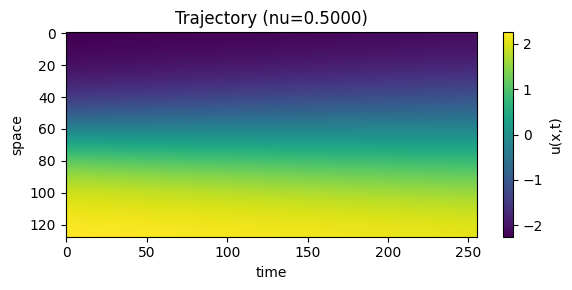

Spatial positions: 128, Time snapshots: 256


In [10]:
dataset = train_loader.dataset
if hasattr(dataset, 'dataset'):
    dataset = dataset.dataset
    
idx = np.random.randint(0, len(dataset))
show_random_sample(dataset, idx)

init_field, true_traj, nu = dataset[0]
T, N = true_traj.shape
print(f"Spatial positions: {N}, Time snapshots: {T}")

### Load model

In [11]:
patch_radius = 1
patch_size = 2 * patch_radius + 1
chunk_size = 5

LOAD_MODEL_NAME = None  # Set to "model.pth" to load saved model

model = TransformerController(patch_size=patch_size, hidden_size=64)

if LOAD_MODEL_NAME is not None:
    print(f"📥 Loading model: {LOAD_MODEL_NAME}")
    model = torch.load(models_dir / LOAD_MODEL_NAME, map_location=device, weights_only=False)

model = model.to(device)

print(f"✓ Model loaded")
print(f"  - Patch size: {patch_size}")
print(f"  - Parameters: {sum(p.numel() for p in model.parameters())}")

✓ Model loaded
  - Patch size: 3
  - Parameters: 8770


### Model training

In [ ]:
num_epochs = 10

print(f"🚀 Training for {num_epochs} epochs...")

train_losses = train_rnn_patch(
    model=model,
    dataloader=train_loader,
    device=device,
    chunk_size=chunk_size,
    num_epochs=num_epochs,
    patch_radius=patch_radius,
    metric="mae"
)

print(f"✓ Training completed! Final loss: {train_losses[-1]:.6f}")

🚀 Training for 10 epochs...


NameError: name 'F' is not defined

### Loss Evolution

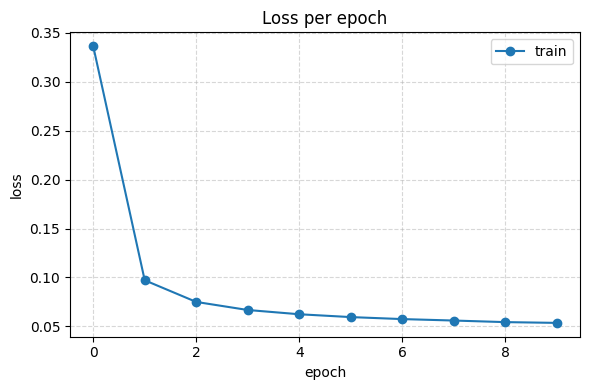

Final loss: 0.053522
Loss reduction: 84.09%


In [ ]:
plot_losses(train_losses)
print(f"Final loss: {train_losses[-1]:.6f}")
print(f"Loss reduction: {((train_losses[0] - train_losses[-1])/train_losses[0]*100):.2f}%")

## Visualization

In [ ]:
PLOT_NU = 'random'  # Options: float, 'min', 'max', 'idx:N', 'random', 'list', None

eval_loader = test_loader if test_loader is not None else train_loader
selected_nu = resolve_nu_target(eval_loader, plot_nu=PLOT_NU, selected_nu=None, list_nus=True, verbose=True)

if selected_nu:
    print(f"✓ Selected nu: {selected_nu}")

Loader contains 5 unique nu values: [0.009999999776482582, 0.026896551251411438, 0.20000000298023224, 0.30000001192092896, 0.432413786649704]
✓ Selected nu: 0.432413786649704


  step 0/251
  step 10/251
  step 20/251
  step 30/251
  step 40/251
  step 50/251
  step 60/251
  step 70/251
  step 80/251
  step 90/251
  step 100/251
  step 110/251
  step 120/251
  step 130/251
  step 140/251
  step 150/251
  step 160/251
  step 170/251
  step 180/251
  step 190/251
  step 200/251
  step 210/251
  step 220/251
  step 230/251
  step 240/251
  step 250/251


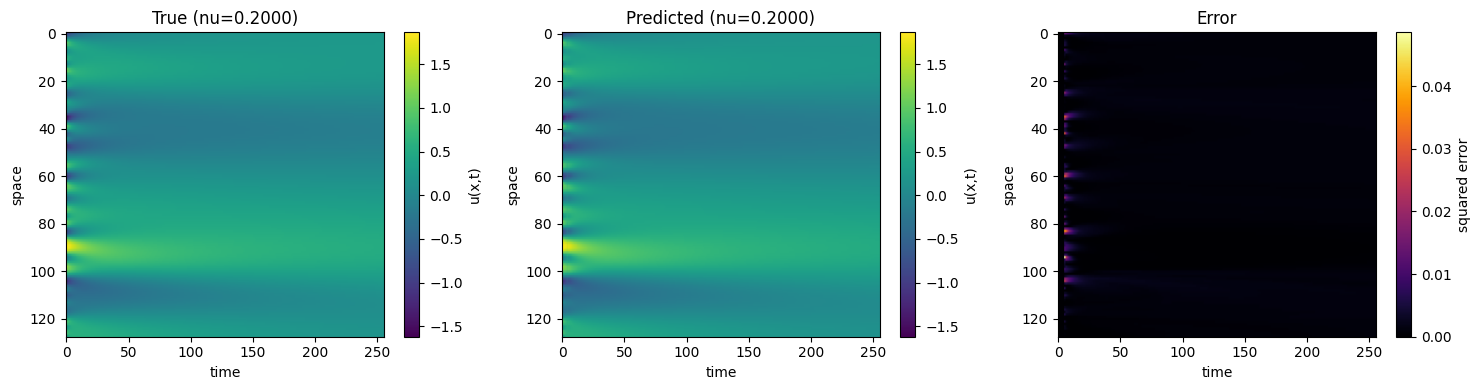

In [ ]:
# The function needs to be fixed in cell 11 to return the values
# For now, let's call rollout_trajectory directly
init_field, true_traj_batch, nu_batch = next(iter(eval_loader))
true_traj = true_traj_batch[0].to(device)
nu_value = float(nu_batch[0].item())

pred_traj = rollout_trajectory(
    model=model,
    true_traj=true_traj,
    nu_value=nu_value,
    device=device,
    patch_radius=patch_radius,
    chunk_size=chunk_size,
    verbose=True,
)

plot_trajectories(true_traj, pred_traj, title_suffix=f" (nu={nu_value:.4f})")

## Evaluation

Evaluation metrics:
  - PSNR: 30.190 dB
  - SSIM: 0.903
  - MSE: 0.000957
  - R²: 0.9873


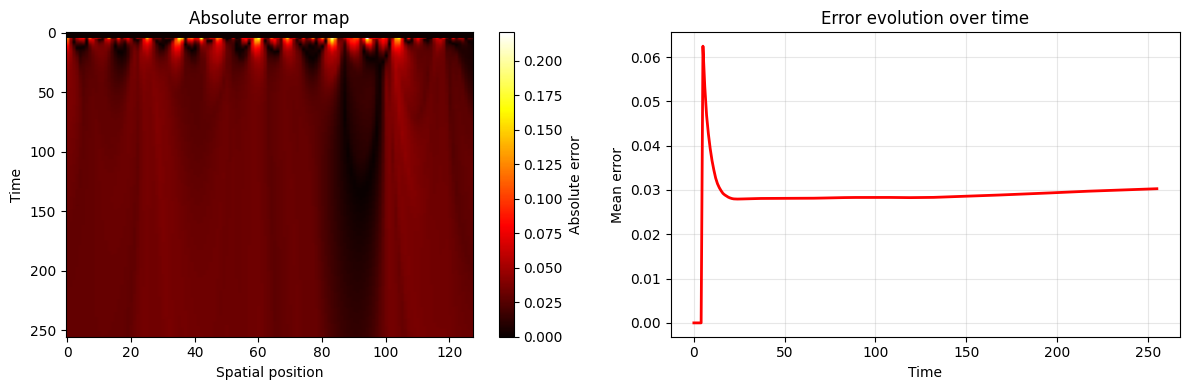

In [ ]:
evaluation_results = evaluate_model_on_sample(
    model,
    eval_loader,
    device,
    patch_radius,
    max_val=1.0,
    val_range=1.0,
    chunk_size=chunk_size,
    nu_target=selected_nu,
)

true_traj, pred_traj = display_evaluation_results(evaluation_results, show_plots=True)

### Mean Absolute Error (MAE)

$$E(t) = \frac{1}{N} \sum_{x=1}^{N} |u_{\text{true}}(t, x) - u_{\text{pred}}(t, x)|$$

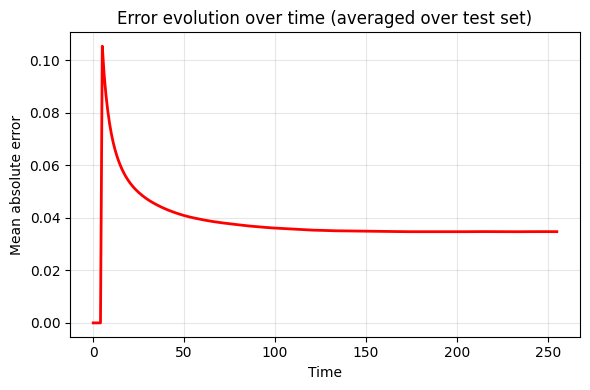

Mean error shape: (256,)


In [ ]:
if test_loader is not None:
    mean_error_per_time = error_evolution_on_loader(
        model, test_loader, device,
        patch_radius=patch_radius,
        chunk_size=chunk_size,
        show_plot=True,
    )
    print(f"Mean error shape: {mean_error_per_time.shape}")

### Save Model (Optional)

In [ ]:
# Uncomment to save model:
# SAVE_MODEL_NAME = "my_trained_model.pth"
# torch.save(model, models_dir / SAVE_MODEL_NAME)
# print(f"✓ Model saved to: {models_dir / SAVE_MODEL_NAME}")

Train loader unique nu values: [0.0010000000474974513, 0.009999999776482582, 0.10000000149011612, 0.5]
